In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

In [2]:
weather = pd.read_excel("/content/drive/MyDrive/weather.xlsx")

In [3]:
X = weather[["Temperature"]]
y = weather["Precipitation (%)"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)


In [5]:
LR = LogisticRegression()
LR.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [6]:
pred = LR.predict(X_test)

In [7]:
print("Weather Prediction Accuracy:", accuracy_score(y_test, pred))

Weather Prediction Accuracy: 0.019444444444444445


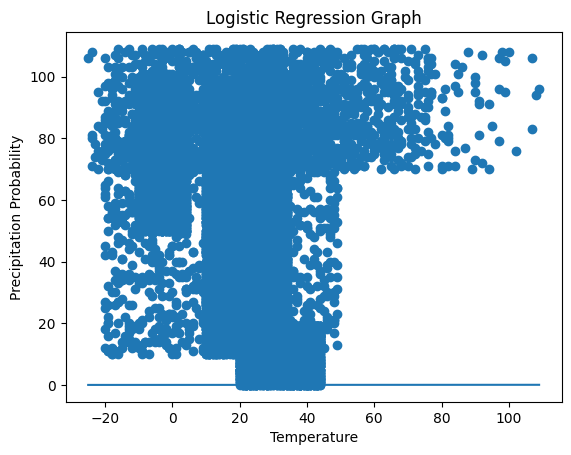

In [9]:


# Sort values for smooth curve
idx = np.argsort(X["Temperature"])
X_sorted = X.iloc[idx]
y_sorted = y.iloc[idx]

# Scatter actual data
plt.scatter(X_sorted, y_sorted)

# Predict probability (sigmoid curve)
y_prob = LR.predict_proba(X_sorted)[:, 1]

# Plot logistic curve
plt.plot(X_sorted, y_prob)

plt.xlabel("Temperature")
plt.ylabel("Precipitation Probability")
plt.title("Logistic Regression Graph")
plt.show()
